In [111]:
import warnings
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score


warnings.filterwarnings('ignore')

In [112]:
df_cust =pd.read_csv(r'C:\Users\suraj\Downloads\Customer.csv')
df_cust.head()

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex
0,CUSTID1,15000,18,44,0
1,CUSTID2,15000,18,79,0
2,CUSTID3,16000,23,8,1
3,CUSTID4,16000,25,79,1
4,CUSTID5,17000,32,41,1


In [113]:
df_cust.shape

(200, 5)

# Check the data type

In [114]:
df_cust.dtypes

Cust_Number         object
Yearly_Income        int64
Age                  int64
Cust_Spend_Score     int64
Sex                  int64
dtype: object

### change the data type of 'sex' object

In [115]:
df_cust['Sex']= df_cust['Sex'].astype('object')

In [116]:
# recheck  the data types of all variable
df_cust.dtypes

Cust_Number         object
Yearly_Income        int64
Age                  int64
Cust_Spend_Score     int64
Sex                 object
dtype: object

In [117]:
df_cust.isnull().sum()

Cust_Number         0
Yearly_Income       0
Age                 0
Cust_Spend_Score    0
Sex                 0
dtype: int64

# Remove insignificant variables

In [118]:
df_cust= df_cust.drop('Cust_Number', axis=1)

### Outliers Analysis

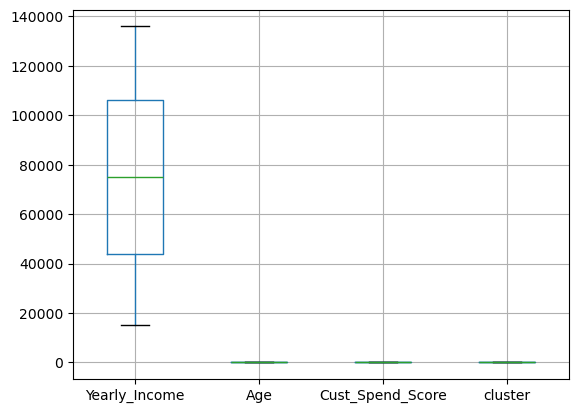

In [139]:
df_cust.boxplot()
plt.show()


# Scale the Data

In [120]:
#consider the features Cust_Spend_Score and Yearly_Income
x_filtered= df_cust[['Yearly_Income','Cust_Spend_Score']]
x_filtered.head()

,Yearly_Income,Cust_Spend_Score
0,15000,44
1,15000,79
2,16000,8
3,16000,79
4,17000,41


In [121]:
# initialize the standardscaler
x_norm= StandardScaler()

#normalize all the columns of the dataframe 'x_filtered'
num_norm= x_norm.fit_transform(x_filtered)

# create a dataframe of scaled numerical variables
x= pd.DataFrame(num_norm,columns= x_filtered.columns)
x.head()

,Yearly_Income,Cust_Spend_Score
0,-1.671568,-0.082595
1,-1.671568,1.237423
2,-1.643461,-1.440328
3,-1.643461,1.237423
4,-1.615353,-0.195740


# K-Means Clustering

### optimal value of K Using Elbow Plot

In [122]:
wcss=[]

for i  in range(1,21):
    kmeans= KMeans(n_clusters= i, random_state=10)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)


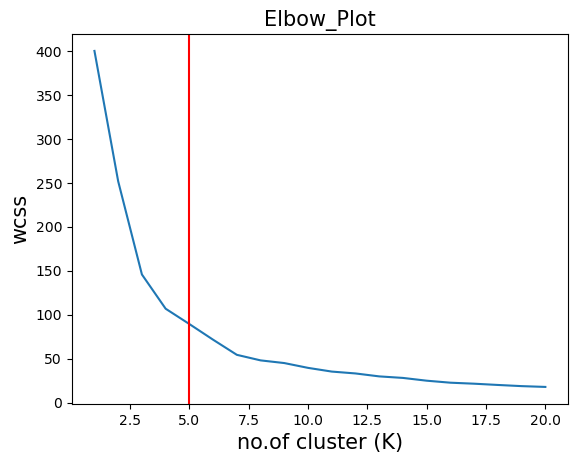

In [141]:
# visualize the elbow plot to get optimal value of K 
plt.plot(range(1,21),wcss)
plt.title('Elbow_Plot',fontsize=15)
plt.xlabel('no.of cluster (K)',fontsize=15)
plt.ylabel('wcss',fontsize=15)


#plot a vertical line at the elbow
plt.axvline(x=5,color= 'red')



#display the plot
plt.show()

### Optimal Value of K Using Silhouette Score

In [124]:
n_clusters= [2,3,4,5,6]

for k in n_clusters:
    cluster= KMeans(n_clusters=k,random_state=10)
    predict= cluster.fit_predict(x)
    score= silhouette_score(x,predict,random_state=10)
    print("for {} clusters the silhouette_score is {}".format(k,score))


for 2 clusters the silhouette_score is 0.34007497544518045
for 3 clusters the silhouette_score is 0.40420921677311
for 4 clusters the silhouette_score is 0.3794744879472294
for 5 clusters the silhouette_score is 0.3532625284200499
for 6 clusters the silhouette_score is 0.3869291076481936


# Build the clusters

In [125]:
new_clusters= KMeans(n_clusters= 5, random_state= 10)

new_clusters.fit(x)
df_cust['cluster']= new_clusters.labels_
df_cust.head()

,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster
0,15000,18,44,0,1
1,15000,18,79,0,0
2,16000,23,8,1,1
3,16000,25,79,1,0
4,17000,32,41,1,1


In [126]:
df_cust.cluster.value_counts()

cluster
2    54
0    38
3    37
1    36
4    35
Name: count, dtype: int64

### plot a barplot to visualize the cluster size

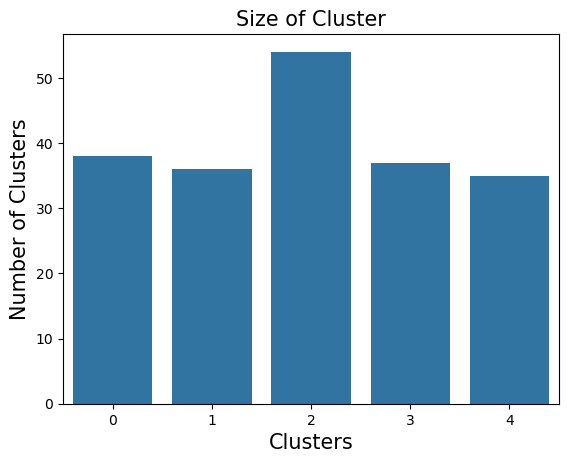

In [127]:
sns.countplot(data= df_cust, x= 'cluster')
plt.title('Size of Cluster',fontsize=15)
plt.xlabel('Clusters',fontsize=15)
plt.ylabel('Number of Clusters',fontsize=15)
plt.show()

### Analyze the Clusters

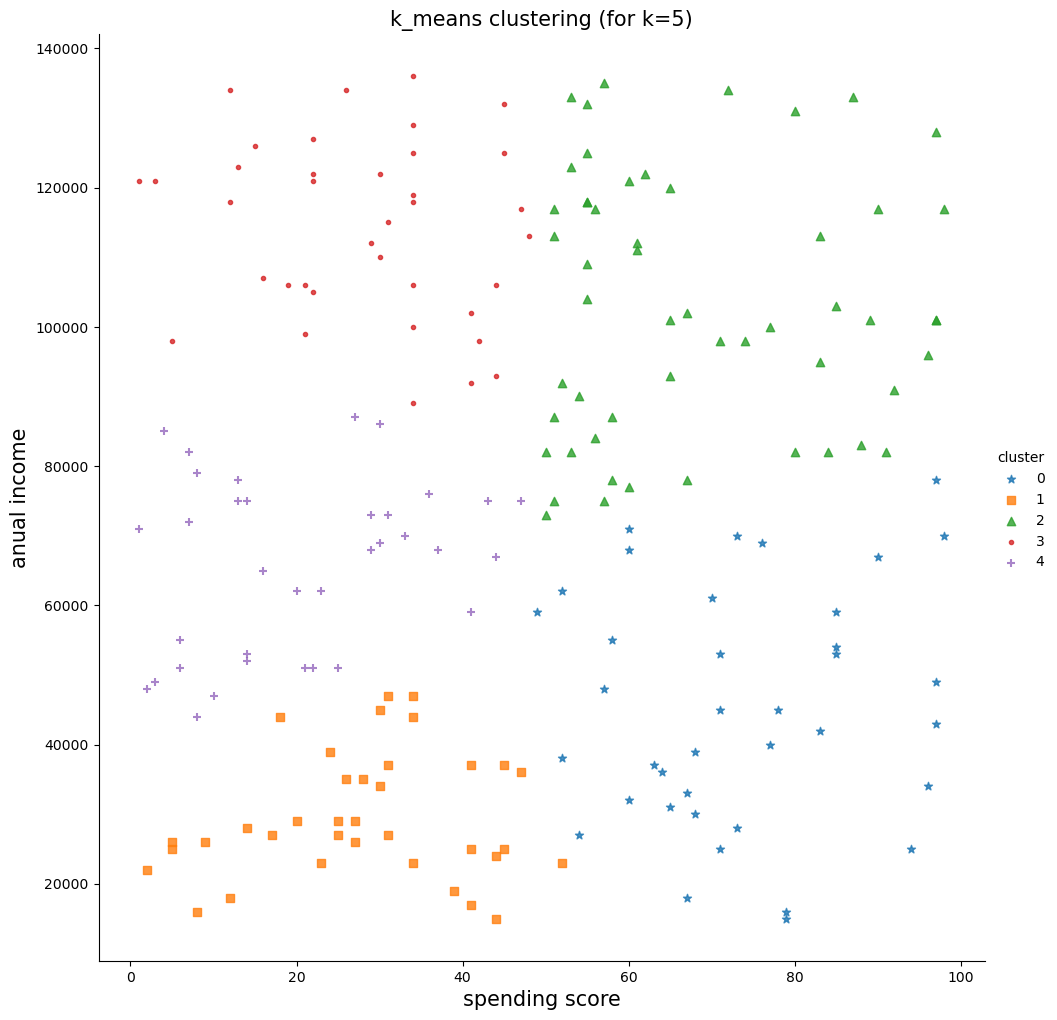

In [128]:
sns.lmplot(x='Cust_Spend_Score',y='Yearly_Income',data=df_cust,hue= 'cluster',markers=['*',',','^','.','+'],fit_reg=False,height=10)
plt.title('k_means clustering (for k=5)',fontsize=15)
plt.xlabel('spending score',fontsize=15)
plt.ylabel('anual income',fontsize=15)

plt.show()

### Cluster 1

In [129]:
# size of a cluster 0
len(df_cust[df_cust['cluster']==0])



38

In [130]:
df_cust[df_cust['cluster']==0].describe()

,Yearly_Income,Age,Cust_Spend_Score,cluster
count,38.000000,38.000000,38.000000,38.0
mean,45394.736842,44.289474,73.394737,0.0
std,17144.125893,16.813617,14.194669,0.0
min,15000.000000,18.000000,49.000000,0.0
25%,32250.000000,29.750000,63.250000,0.0
50%,44000.000000,44.000000,71.000000,0.0
75%,59000.000000,60.750000,84.500000,0.0
max,78000.000000,69.000000,98.000000,0.0


### Cluster 2

In [131]:
# size of a cluster 1
len(df_cust[df_cust['cluster']==1])

36

In [132]:
df_cust[df_cust['cluster']==1].describe()

,Yearly_Income,Age,Cust_Spend_Score,cluster
count,36.000000,36.000000,36.000000,36.0
mean,29611.111111,48.972222,28.027778,1.0
std,8909.955196,15.621388,13.196290,0.0
min,15000.000000,18.000000,2.000000,1.0
25%,23750.000000,37.000000,19.500000,1.0
50%,27000.000000,49.000000,29.000000,1.0
75%,36250.000000,64.250000,39.500000,1.0
max,47000.000000,70.000000,52.000000,1.0


### Cluster 3

In [133]:
# size of a cluster 2
len(df_cust[df_cust['cluster']==2])

54

In [134]:
df_cust[df_cust['cluster']==2].describe()

,Yearly_Income,Age,Cust_Spend_Score,cluster
count,54.000000,54.000000,54.000000,54.0
mean,103185.185185,43.740741,68.240741,2.0
std,18481.070452,13.852573,15.892249,0.0
min,73000.000000,19.000000,50.000000,2.0
25%,87000.000000,33.250000,55.000000,2.0
50%,101000.000000,44.500000,61.500000,2.0
75%,117750.000000,54.000000,83.000000,2.0
max,135000.000000,68.000000,98.000000,2.0


### Cluster 4

In [135]:
# size of a cluster 3
len(df_cust[df_cust['cluster']==3])

37

In [136]:
df_cust[df_cust['cluster']==2].describe()

,Yearly_Income,Age,Cust_Spend_Score,cluster
count,54.000000,54.000000,54.000000,54.0
mean,103185.185185,43.740741,68.240741,2.0
std,18481.070452,13.852573,15.892249,0.0
min,73000.000000,19.000000,50.000000,2.0
25%,87000.000000,33.250000,55.000000,2.0
50%,101000.000000,44.500000,61.500000,2.0
75%,117750.000000,54.000000,83.000000,2.0
max,135000.000000,68.000000,98.000000,2.0


### Cluster 5

In [137]:
# size of a cluster 4
len(df_cust[df_cust['cluster']==4])

35

In [138]:
df_cust[df_cust['cluster']==2].describe()

,Yearly_Income,Age,Cust_Spend_Score,cluster
count,54.000000,54.000000,54.000000,54.0
mean,103185.185185,43.740741,68.240741,2.0
std,18481.070452,13.852573,15.892249,0.0
min,73000.000000,19.000000,50.000000,2.0
25%,87000.000000,33.250000,55.000000,2.0
50%,101000.000000,44.500000,61.500000,2.0
75%,117750.000000,54.000000,83.000000,2.0
max,135000.000000,68.000000,98.000000,2.0
